### Extract spike timeseries aligned to specific event for every unit

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
from imports import *
import scipy.io
from config import dir_config, ephys_config
from src.utils import ephys_utils
import pickle
from scipy.stats import ttest_rel

compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

# Function to compute spike counts for fixed-interval epochs
def get_spike_counts(cluster_spike_time, timestamps, trial_info, alignment_settings, sampling_rate=30):
    result = {}
    for epoch in alignment_settings.keys():
        n_trials = len(trial_info)
        spike_counts = np.full((n_trials, 1), np.nan, dtype=float)
        duration = (alignment_settings[epoch]['end_time_ms'] - alignment_settings[epoch]['start_time_ms']) / 1000
        for idx_trial, trial_num in enumerate(trial_info.index):
            if np.isnan(trial_info.reaction_time[trial_num]):
                continue
            aligned_event_time = timestamps.loc[trial_num, alignment_settings[epoch]['event']]
            start_timestamp = aligned_event_time + alignment_settings[epoch]['start_time_ms'] * sampling_rate
            end_timestamp   = aligned_event_time + alignment_settings[epoch]['end_time_ms']   * sampling_rate
            temp_spike_times = cluster_spike_time[
                (cluster_spike_time >= start_timestamp) & (cluster_spike_time <= end_timestamp)
            ]
            spike_counts[idx_trial] = len(temp_spike_times)
        result[epoch] = spike_counts / duration
    return result


def get_delay_visual_spike_counts(cluster_spike_time, timestamps, trial_info,
                                   start_offset_ms=250, end_offset_ms=-100,
                                   window_ms=100, step_ms=50, sampling_rate=30):
    """
    For each trial, compute firing rate in each rolling 100ms window spanning
    from target_onset + 250ms to go_onset - 300ms.
    Returns array of shape (n_trials, max_windows); NaN where a window is absent.
    """
    window_samples = window_ms * sampling_rate
    step_samples   = step_ms   * sampling_rate
    duration_sec   = window_ms / 1000.0

    # First pass: collect per-trial window rates
    all_win_rates = []
    for trial_num in trial_info.index:
        if np.isnan(trial_info.reaction_time[trial_num]):
            all_win_rates.append([])
            continue
        delay_start = timestamps.loc[trial_num, 'target_onset'] + start_offset_ms * sampling_rate
        delay_end   = timestamps.loc[trial_num, 'go_onset']     + end_offset_ms   * sampling_rate
        if delay_end <= delay_start + window_samples:
            all_win_rates.append([])
            continue
        win_rates = []
        win_start = delay_start
        while win_start + window_samples <= delay_end:
            spikes = cluster_spike_time[
                (cluster_spike_time >= win_start) & (cluster_spike_time < win_start + window_samples)
            ]
            win_rates.append(len(spikes) / duration_sec)
            win_start += step_samples
        all_win_rates.append(win_rates)

    max_windows = max((len(w) for w in all_win_rates), default=1)
    result = np.full((len(trial_info), max_windows), np.nan)
    for i, win_rates in enumerate(all_win_rates):
        if win_rates:
            result[i, :len(win_rates)] = win_rates
    return result


In [ ]:

# Load neuron metadata
neuron_metadata = pd.read_csv(Path(processed_dir, "neuron_metadata.csv"), index_col=None)
spike_rate_neuron_wise = {neuron: {} for neuron in neuron_metadata.neuron_id}

# Main loop for each neuron
for neuron in neuron_metadata.neuron_id:
    session_name = neuron_metadata.session_id[neuron_metadata.neuron_id == neuron].values[0]
    cluster_id = neuron_metadata.cluster[neuron_metadata.neuron_id == neuron].values[0]

    # Load required data
    timestamps_path = Path(compiled_dir, session_name, f"{session_name}_timestamps_cleaned.csv")
    trial_info_path = Path(compiled_dir, session_name, f"{session_name}_trial_cleaned.csv")
    spike_times_path = Path(compiled_dir, session_name, "spike_times.npy")
    spike_clusters_path = Path(compiled_dir, session_name, "spike_clusters.npy")
    spike_times_mat_path = Path(compiled_dir, session_name, "spike_times.mat")
    spike_clusters_mat_path = Path(compiled_dir, session_name, "spike_clusters.mat")

    if not (timestamps_path.is_file() and trial_info_path.is_file()):
        print(f"Missing files for session: {session_name}")
        continue

    timestamps = pd.read_csv(timestamps_path, index_col=None)
    trial_info = pd.read_csv(trial_info_path, index_col=None)

    # Load spike data
    if spike_times_path.is_file() and spike_clusters_path.is_file():
        spike_times = np.load(spike_times_path)
        spike_clusters = np.load(spike_clusters_path)
    elif spike_times_mat_path.is_file() and spike_clusters_mat_path.is_file():
        spike_times = scipy.io.loadmat(spike_times_mat_path)["spike_times"].ravel()
        spike_clusters = scipy.io.loadmat(spike_clusters_mat_path)["spike_clusters"].ravel()
    else:
        print(f"Spike times and clusters not found in {session_name} for neuron {neuron}")
        continue

    # Filter spike times for the current cluster
    cluster_spike_time = spike_times[spike_clusters == cluster_id]
    VGS_trial_info = trial_info[(trial_info.task_type == 2) & ((trial_info.outcome) == 1)]  # VGS trials with correct outcome 
    # only include trials with non-nan reaction time
    VGS_trial_info = VGS_trial_info[~VGS_trial_info.reaction_time.isna()]
    # only include trials with toRF choice
    VGS_trial_info = VGS_trial_info[VGS_trial_info.choice == 1]
    
    # Get aligned and convolved spike trains
    alignment_settings_classification = {
        'baseline':      {'event': 'target_onset',   'start_time_ms': -100, 'end_time_ms':    0},
        'visual':        {'event': 'target_onset',   'start_time_ms':   50, 'end_time_ms':  150},
        'delay_saccade': {'event': 'response_onset', 'start_time_ms': -400, 'end_time_ms': -200},
        'saccade':       {'event': 'response_onset', 'start_time_ms':  -50, 'end_time_ms':    0},
    }
    results = get_spike_counts(cluster_spike_time, timestamps, VGS_trial_info, alignment_settings_classification)
    results['delay_visual'] = get_delay_visual_spike_counts(cluster_spike_time, timestamps, VGS_trial_info)

    spike_rate_neuron_wise[neuron] = results
    

## classification (adpated from Li and Basso 2008)

In [ ]:
def classify_neuron(baseline, visual, delay_visual, delay_saccade, saccade):
    """
    Classify neuron type based on spike discharge rates.

    Inputs:
        baseline      : array-like, shape (n_trials, 1)
        visual        : array-like, shape (n_trials, 1)
        delay_visual  : array-like, shape (n_trials, n_windows) -- per-window rates, NaN-padded
        delay_saccade : array-like, shape (n_trials, 1)
        saccade       : array-like, shape (n_trials, 1)

    Classification criteria (t-test p < 0.05 + mean comparison):
        visual_response : mean(visual) > mean(baseline)
        delay_response  : any rolling window has mean > mean(baseline) with p < 0.05
        motor_response  : mean(saccade) > mean(delay_saccade)

    Output label based on (visual, delay, motor):
        (1,0,0) -> visual_phasic
        (0,0,1) -> motor
        (*,1,0) -> visual_tonic
        (*,*,1) with visual or delay -> visuomotor
        (0,0,0) -> undefined

    Returns:
        label                     : str
        visual_response           : bool
        delay_response            : bool
        motor_response            : bool
        visual_response_magnitude : float  (mean visual - mean baseline, Hz)
        motor_response_magnitude  : float  (mean saccade - mean delay_saccade, Hz)
    """
    b  = baseline.ravel()
    v  = visual.ravel()
    ds = delay_saccade.ravel()
    s  = saccade.ravel()

    # Valid trials for non-delay epochs
    valid = ~(np.isnan(b) | np.isnan(v) | np.isnan(ds) | np.isnan(s))

    _, p_vis = ttest_rel(v[valid], b[valid])
    _, p_mot = ttest_rel(s[valid], ds[valid])

    

    visual_response_magnitude = float(np.mean(v[valid]) - np.mean(b[valid]))
    motor_response_magnitude  = float(np.mean(s[valid]) - np.mean(ds[valid]))

    visual_response = bool(((np.mean(v[valid]) > np.mean(b[valid])) and p_vis < 0.05) and visual_response_magnitude > 3) 
    motor_response  = bool(((np.mean(s[valid]) > np.mean(ds[valid])) and p_mot < 0.05) and motor_response_magnitude > 5)

    # delay_response: positive if ANY rolling window is significantly > baseline
    dv = np.atleast_2d(delay_visual) if delay_visual.ndim > 1 else delay_visual[:, np.newaxis]
    delay_response = False
    for w in range(dv.shape[1]):
        win = dv[:, w]
        valid_w = ~(np.isnan(b) | np.isnan(win))
        if valid_w.sum() < 2:
            continue
        win_v  = win[valid_w]
        base_v = b[valid_w]
        if np.mean(win_v) > np.mean(base_v):
            _, p_w = ttest_rel(win_v, base_v)
            if p_w < 0.05:
                delay_response = True
                break

    if motor_response and (delay_response or visual_response):
        label = 'visuomotor'
    elif motor_response:
        label = 'motor'
    elif delay_response:
        label = 'visual_tonic'
    elif visual_response:
        label = 'visual_phasic'
    else:
        label = 'undefined'

    return label, visual_response, delay_response, motor_response, visual_response_magnitude, motor_response_magnitude


In [ ]:
neuron_metadata = pd.read_csv(Path(processed_dir, "neuron_metadata.csv"), index_col=None)

In [ ]:
rows = []
for neuron in neuron_metadata.neuron_id:
    baseline_data     = spike_rate_neuron_wise[neuron]['baseline']
    visual_data       = spike_rate_neuron_wise[neuron]['visual']
    delay_visual_data = spike_rate_neuron_wise[neuron]['delay_visual']
    delay_sacc_data   = spike_rate_neuron_wise[neuron]['delay_saccade']
    saccade_data      = spike_rate_neuron_wise[neuron]['saccade']

    label, vis, dly, mot, vis_mag, mot_mag = classify_neuron(
        baseline_data, visual_data, delay_visual_data, delay_sacc_data, saccade_data
    )
    neuron_metadata.loc[neuron_metadata.neuron_id == neuron, 'classification_new'] = label
    rows.append({'neuron_id': neuron, 'visual_response': vis, 'delay_response': dly,
                 'motor_response': mot, 'classification': label,
                 'visual_response_magnitude': vis_mag, 'motor_response_magnitude': mot_mag})


classification_df = pd.DataFrame(rows)
classification_df.to_csv(Path(processed_dir, "neuron_classification.csv"), index=False)
print(f"\nSaved {len(classification_df)} neurons to neuron_classification.csv")
classification_df


In [ ]:
neuron_metadata.to_csv(Path(processed_dir, "neuron_metadata.csv"), index=False)

In [3]:
neuron_metadata = pd.read_csv(Path(processed_dir, "neuron_metadata.csv"), index_col=None)

Text(0, 0.5, '')

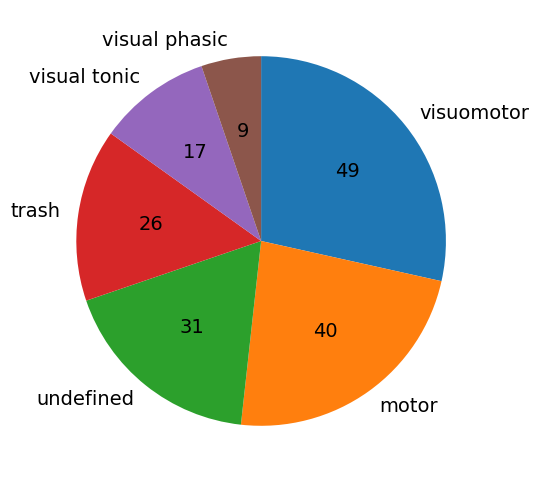

In [4]:
plt.figure(figsize=(6,6))
counts = neuron_metadata['classification'].value_counts()
labels = counts.index.str.replace('_', ' ', regex=False)
def absolute_only(pct, all_vals):
    absolute = int(round(pct/100. * sum(all_vals)))
    return f"{absolute}"

counts.plot.pie(
    labels=labels,                          # show classification types
    autopct=lambda pct: absolute_only(pct, counts),
    startangle=90,
    counterclock=False,
    fontsize=14
)

plt.ylabel('')
# plt.show()
# plt.savefig(Path(processed_dir, "dissemination","neuron_classification_pie_chart.png"))
# plt.show()

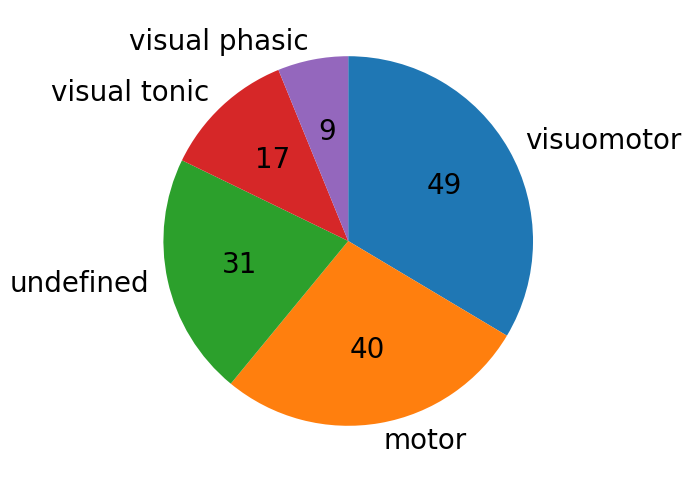

<Figure size 640x480 with 0 Axes>

In [8]:
plt.figure(figsize=(6,6))
# exclude the trash type from the pie chart
neuron_metadata_no_trash = neuron_metadata[neuron_metadata['classification'] != 'trash']
counts = neuron_metadata_no_trash['classification'].value_counts()
labels = counts.index.str.replace('_', ' ', regex=False)
def absolute_only(pct, all_vals):
    absolute = int(round(pct/100. * sum(all_vals)))
    return f"{absolute}"

counts.plot.pie(
    labels=labels,                          # show classification types
    autopct=lambda pct: absolute_only(pct, counts),
    startangle=90,
    counterclock=False,
    fontsize=20
)

plt.ylabel('')
plt.show()
plt.savefig(Path(processed_dir, "dissemination","neuron_classification_no_trash_pie_chart.png"))
# plt.show()